Here, I will demonstrate how we run simulations with self-gravity.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'STIXGeneral'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# Add particles

In [2]:
from ezfalcon.tools import mkPlummer_galpy
pos, vel, masses = mkPlummer_galpy(m=1e10, b = 2, n=5000)

from ezfalcon.simulation import Sim
sim = Sim()
sim.add_particles('stars', pos, vel, mass=masses)

# Running the simulation

In [3]:
sim.run(t_end=0.1, dt=0.0001, dt_out=0.001, eps=0.01, theta=0.5, kernel=1)

  1%|          | 6/1000 [00:00<00:17, 58.11it/s]

100%|██████████| 1000/1000 [00:14<00:00, 70.92it/s]


# Diagnostics

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1049: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



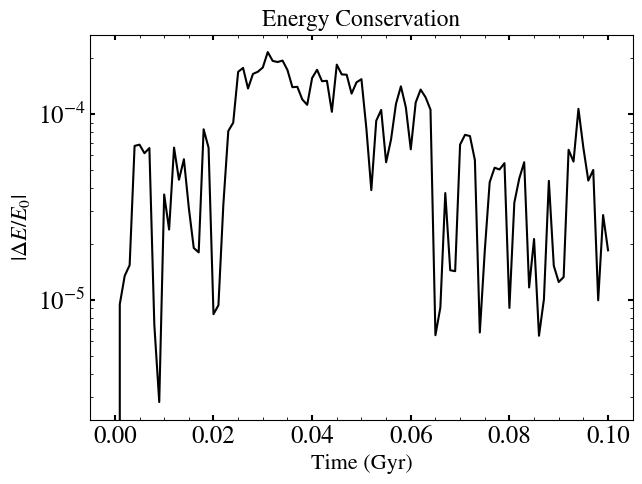

In [4]:
# calculated with same technique as for the integration
# 
sim.plot_energy_diagnostic()

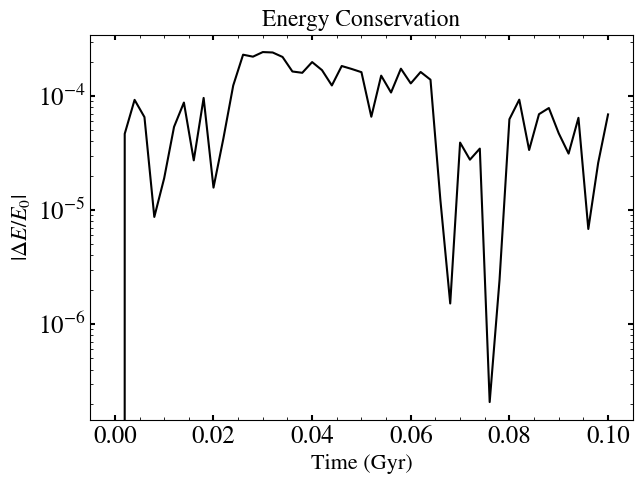

In [5]:
# Energy diagnostic recalculated with direct summation
# to check that the tree code is not introducing significant energy errors.

sim.plot_energy_diagnostic(method='direct_C', eps=0.01, nsnap=50)

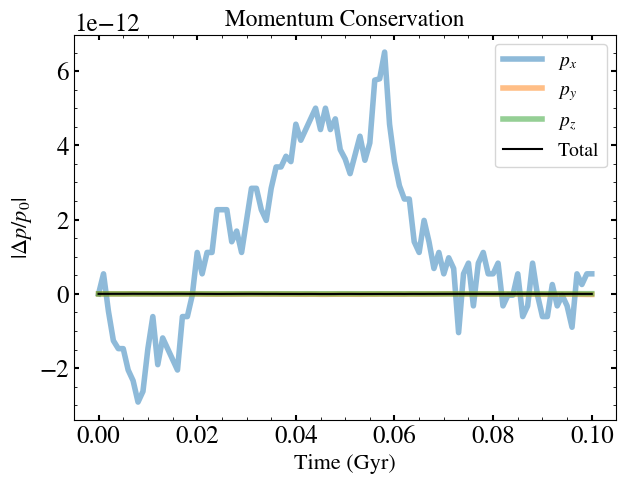

In [6]:
sim.plot_momentum_diagnostic()

# Visualizations

/tmp/ipykernel_2561037/2684468917.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()



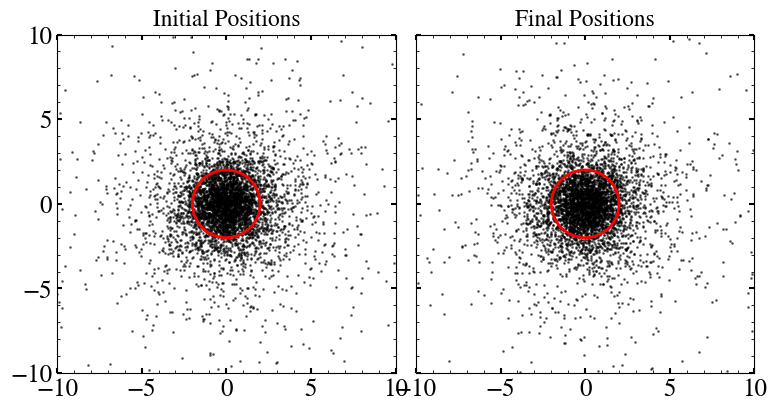

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharex=True, sharey=True, gridspec_kw={'wspace': 0.06})

# Initial positions
axes[0].scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
axes[0].add_artist(circle)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
# axes[0].set_xlabel('x [kpc]')
# axes[0].set_ylabel('y [kpc]')
axes[0].set_title('Initial Positions')
axes[0].set_aspect('equal')

# Final positions

axes[1].scatter(sim.x(-1), sim.y(-1), s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
axes[1].add_artist(circle)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
# axes[1].set_xlabel('x [kpc]')
# axes[1].set_ylabel('y [kpc]')
axes[1].set_title('Final Positions')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//2  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2, ls='--', zorder=4, alpha=1.0)
ax_anim.scatter(0, 0, s=50, c='r', marker='+', zorder=5)
ax_anim.add_artist(circle)
sc = ax_anim.scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.5)

ax_anim.set_xlim(-10, 10)
ax_anim.set_ylim(-10, 10)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
ax_anim.set_aspect('equal')
title = ax_anim.set_title('t = 0', fontsize=22)

def update(i):
    i *= 2
    sc.set_offsets(list(zip(sim.x(i), sim.y(i))))
    title.set_text(f't = {sim.times[i]*1000:.0f} Myr')
    return sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=100, blit=False)
plt.close(fig_anim)
fig_anim.tight_layout()
anim.save(
    'plummer_evolution.gif',
    writer='pillow',
    fps=20
)

In [9]:
#HTML(anim.to_jshtml())


**Other Features**
* self-gravity of individual components (choice to calculate with or without other components)
* many different ways to assign softening lengths